# **Регресійний аналіз аналіз даних та візуалізація засобами Python**
---



**Коваріація та кореляція** <br>
<br>
Перейдемо до аналізу взаємозв’язків між двома змінними.<br>
Коваріація – міра лінійної залежності двох випадкових величин одна від одної.<br>
Кореляція – зважена версія коваріації.<br>
Коефіцієнт кореляції (ще має назву коефіцієнт Пірсона)<br>

<br>
Властивості коефіцієнта кореляції:<br>
• коефіцієнт кореляції не змінюється при зміні одиниць виміру(наприклад
від кілограм до грам)<br>
• коефіцієнт кореляції є симетричним r(x, y) = r(y, x)<br>
• коефіцієнт кореляції чутливий до викидів<br><br>
Лінійна регресія<br>
Якщо коефіцієнт кореляції дає нам розуміння чи є лінійна залежність між двома
змінними, то лінійна регресія дає модель для оцінки як зміниться одна змінна при
зміні іншої. Наприклад, може визначити, як вага дорослої анаконди при зміні її
довжини.

Наступний код д використовує бібліотеку pandas для завантаження даних з
файлу anaconda.dat, а потім проводить кілька операцій з даними.

1. pd.read_csv('anaconda.dat', sep='\t', names=['X', 'Y', 'Gender']): Цей рядок
завантажує дані з файлу anaconda.dat з використанням роздільника табуляції ('\t') та
встановлює назви стовпців на 'X', 'Y', та 'Gender'. Функція pd.read_csv() повертає
об'єкт DataFrame, який зберігає ці дані.
2. print(df.head()): Цей рядок виводить перші п'ять рядків з DataFrame df, який
містить завантажені дані.
3. print(df.dtypes): Цей рядок виводить типи даних для кожного стовпця
DataFrame df.
4. df['Gender'] = df['Gender'].map({'M': 0, 'F': 1}): Цей рядок змінює значення в
стовпці 'Gender', замінюючи значення 'M' на 0 та 'F' на 1.
5. print(df.head()): Цей рядок виводить перші п'ять рядків DataFrame df після
заміни значень в стовпці 'Gender'.
6. correlation = df.corr(): Цей рядок обчислює матрицю кореляції для всіх стовпців
у DataFrame df та зберігає її в змінну correlation.
print(correlation): Цей рядок виводить матрицю кореляції, яка містить коефіцієнти
кореляції між кожною парою стовпців у DataFrame df.

In [1]:
import pandas as pd
import gdown

google_drive_url = 'https://drive.google.com/file/d/1qiUOSQSTtZ1l9kvBe0HKISS9qS2UWK-K'

file_id = google_drive_url.split('/')[-1]

gdown.download(f'https://drive.google.com/uc?id={file_id}', 'anaconda.dat', quiet=False)

# Завантаження даних з файлу anaconda.dat
df = pd.read_csv('/content/anaconda.dat', sep='\t', names=['X', 'Y', 'Gender'], header=None)

# Виведення перших 5 рядків даних
print(df.head())

# Перевірка типів даних у колонках
print(df.dtypes)

# Заміна значень "M" та "F" на відповідно числові значення
df['Gender'] = df['Gender'].map({'M': 0, 'F': 1})

# Перевірка заміни значень
print(df.head())

# Розрахунок коефіцієнта кореляції Пірсона
correlation = df.corr()

# Виведення матриці кореляції
print(correlation)

Downloading...
From: https://drive.google.com/uc?id=1qiUOSQSTtZ1l9kvBe0HKISS9qS2UWK-K
To: /content/anaconda.dat
100%|██████████| 758/758 [00:00<00:00, 385kB/s]

       X     Y Gender
0  271.0  18.5      F
1  477.0  82.5      F
2  306.3  23.4      F
3  365.3  33.5      F
4  466.0  69.0      F
X         float64
Y         float64
Gender     object
dtype: object
       X     Y  Gender
0  271.0  18.5       1
1  477.0  82.5       1
2  306.3  23.4       1
3  365.3  33.5       1
4  466.0  69.0       1
               X         Y    Gender
X       1.000000  0.961387  0.766122
Y       0.961387  1.000000  0.729934
Gender  0.766122  0.729934  1.000000


Наступний код будує лінійну регресію та виводить візуалізації для аналізу залежності між двома змінними.

1. Спочатку, імпортується необхідні бібліотеки Pandas, NumPy, Matplotlib,
LinearRegression та r2_score з scikit-learn.
2. Далі, завантажується файл даних 'anaconda.dat' зі значеннями X, Y та Gender у
DataFrame.
3. Замінюються значення 'M' та 'F' у колонці 'Gender' на відповідно числові
значення 0 та 1.
4. Дані розділяються на окремі колонки X та Y та підготовлюються для побудови
моделі лінійної регресії.
5. Лінійна регресія побудовується на основі значень X та Y.
6. Прогнозні значення Y_pred отримуються на основі моделі лінійної регресії.
7. Коефіцієнт кореляції Пірсона розраховується для оцінки ступеня лінійної
залежності між змінними X та Y.
8. Коефіцієнт детермінації (R^2) розраховується для оцінки точності побудованої
моделі.
9. Побудовується графік, який показує залежність між X та Y та включає лінію
лінійної регресії.
10.Побудовується візуалізація залишків для перевірки на випадковість помилок
моделі.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Завантаження даних з файлу anaconda.dat
df = pd.read_csv('anaconda.dat', sep='\t', names=['X', 'Y', 'Gender'])

# Заміна значень "M" та "F" на відповідно числові значення
df['Gender'] = df['Gender'].map({'M': 0, 'F': 1})

# Розділення даних на окремі колонки
X = df['X'].values.reshape(-1, 1)
Y = df['Y'].values

# Побудова лінійної регресії
regression = LinearRegression()
regression.fit(X, Y)

# Отримання прогнозних значень
Y_pred = regression.predict(X)

# Розрахунок коефіцієнта кореляції Пірсона
correlation = df[['X', 'Y']].corr().iloc[0, 1]

# Розрахунок коефіцієнта детермінації (R^2)
r2 = r2_score(Y, Y_pred)


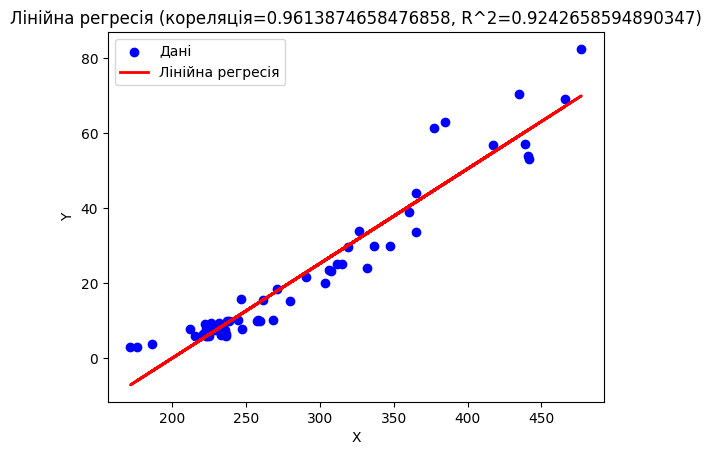

In [ ]:
# Побудова графіка регресії
plt.scatter(X, Y, color='blue', label='Дані')
plt.plot(X, Y_pred, color='red', linewidth=2, label='Лінійна регресія')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Лінійна регресія (кореляція={correlation}, R^2={r2})')
plt.legend()
plt.show()


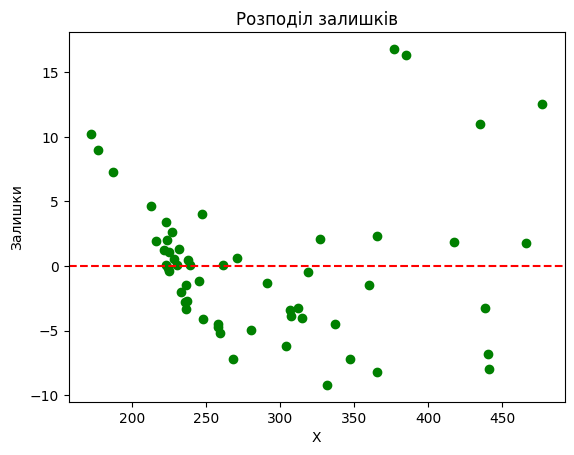

In [ ]:
# Розрахунок та візуалізація залишків
residuals = Y - Y_pred
plt.scatter(X, residuals, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('X')
plt.ylabel('Залишки')
plt.title('Розподіл залишків')
plt.show()

Умови для побудови лінійної регресії:

* Лінійність (тобто наявність лінійної залежності між незалежною та залежною змінною)
* Нормальний розподіл залишків
* Гомоскедастичність (стала варіативність залишків)
<br>
<br>
За цим посиланням https://gallery.shinyapps.io/slr_diag/
ви можете змоделювати
дані з різними типами залежності та дослідити, як при цьому будуть виглядати лінія
регресії, коефіцієнт кореляції, та як виглядає розподіл залишків.